# **Import Libraries and Frameworks**

In [ ]:
import warnings
warnings.filterwarnings('ignore')

!pip install langdetect -q

import numpy as np
import random
import zipfile
import json
import re
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import drive
from collections import Counter
from datasets import Dataset
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0  # make results reproducible

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 38.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


# **Import Dataset**

In [ ]:
drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/astronomy_dataset.zip'
extract_to = '/content/my_data'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

Mounted at /content/drive


# **Convert Dataset to DataFrame**

In [ ]:
# Path to your JSON file
json_path = '/content/my_data/astronomy_dataset/data.json'

# Load JSON data
with open(json_path, 'r') as f:
    data = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(data)

# Display first few rows
df.head()

,image_id,text,image
0,001,A satellite image of Earth showing the curvatu...,images/001.jpg
1,002,A view of Earth from orbit highlighting the de...,images/002.jpg
2,003,An image of Earth taken from space showing Nor...,images/003.jpg
3,004,A high-resolution view of Earth revealing the ...,images/004.jpg
4,005,A space-based image of Earth showing the curva...,images/005.jpg


# **EDA Steps**

In [ ]:
# Check for missing values in each column
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
image_id    0
text        0
image       0
dtype: int64


In [ ]:
empty_strings = (df == "").sum()
print("\nEmpty strings in each column:")
print(empty_strings)


Empty strings in each column:
image_id    0
text        0
image       0
dtype: int64


In [ ]:
# Basic info
print("Number of captions:", len(df))
print("Unique captions:", df['text'].nunique())

# Show a few random captions
df['text'].sample(5, random_state=42)

Number of captions: 250
Unique captions: 250


,text
142,An image showing Hubble’s metallic body glinti...
6,A distant perspective of Earth capturing the b...
97,A detailed orbital view of Mars highlighting d...
60,A high-resolution image of Mars showing ancien...
112,A high-resolution image of Hubble’s reflective...


Average caption length (characters): 93.916
Average caption length (words): 15.208


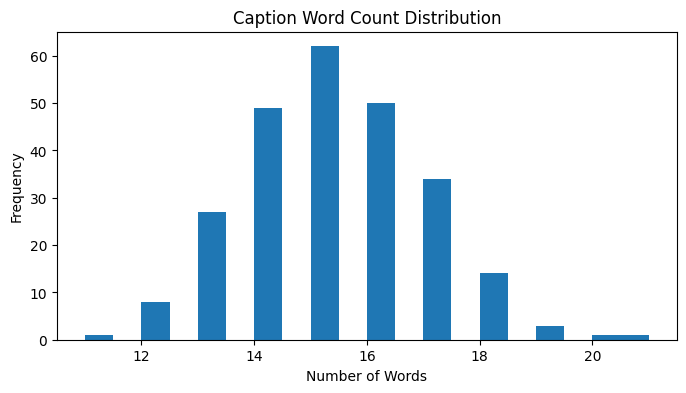

In [ ]:
# Create a new column for caption lengths
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

print("Average caption length (characters):", df['text_length'].mean())
print("Average caption length (words):", df['word_count'].mean())

# Plot distributions
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(df['word_count'], bins=20)
plt.title("Caption Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

Top 20 Most Common Words:

the: 298
a: 278
of: 217
showing: 144
image: 116
and: 100
mars: 96
earth: 61
space: 53
view: 52
with: 51
milky: 50
photograph: 44
hubble: 43
an: 42
in: 42
telescope: 39
way: 38
from: 35
its: 33
[('the', 298), ('a', 278), ('of', 217), ('showing', 144), ('image', 116), ('and', 100), ('mars', 96), ('earth', 61), ('space', 53), ('view', 52), ('with', 51), ('milky', 50), ('photograph', 44), ('hubble', 43), ('an', 42), ('in', 42), ('telescope', 39), ('way', 38), ('from', 35), ('its', 33)]


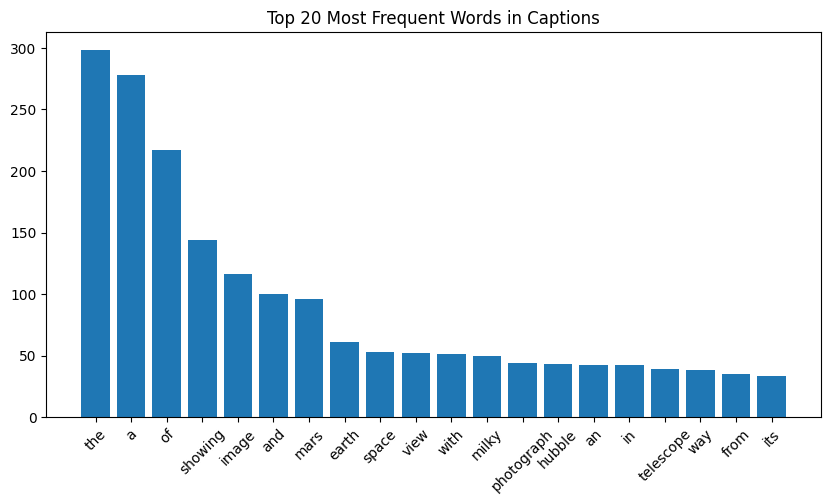

In [ ]:
# Simple preprocessing: lowercase, remove punctuation
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

# Combine all text
all_words = " ".join(df['text'].apply(clean_text)).split()

# Count most common words
word_freq = Counter(all_words).most_common(20)
print("Top 20 Most Common Words:\n")
for word, count in word_freq:
    print(f"{word}: {count}")
print(word_freq)

# Optional: visualize
words, counts = zip(*word_freq)
plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Top 20 Most Frequent Words in Captions")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Duplicated captions
duplicates = df[df.duplicated('text', keep=False)]
print("Number of duplicated captions:", len(duplicates))

# Very short captions
short_captions = df[df['word_count'] < 3]
print("Very short captions:")
print(short_captions[['image_id', 'text']].head())

Number of duplicated captions: 0
Very short captions:
Empty DataFrame
Columns: [image_id, text]
Index: []


In [ ]:
# Try detecting language for each caption safely
def safe_detect(text):
    try:
        return detect(text)
    except:
        return "error"

df['language'] = df['text'].apply(safe_detect)

# Show frequency of detected languages
print(df['language'].value_counts())

# If we need to filter non English data
non_english = df[df['language'] != 'en']
print(non_english[['image_id', 'text', 'language']])
# To keep only English captions
df = df[df['language'] == 'en'].reset_index(drop=True)

language
en    250
Name: count, dtype: int64
Empty DataFrame
Columns: [image_id, text, language]
Index: []


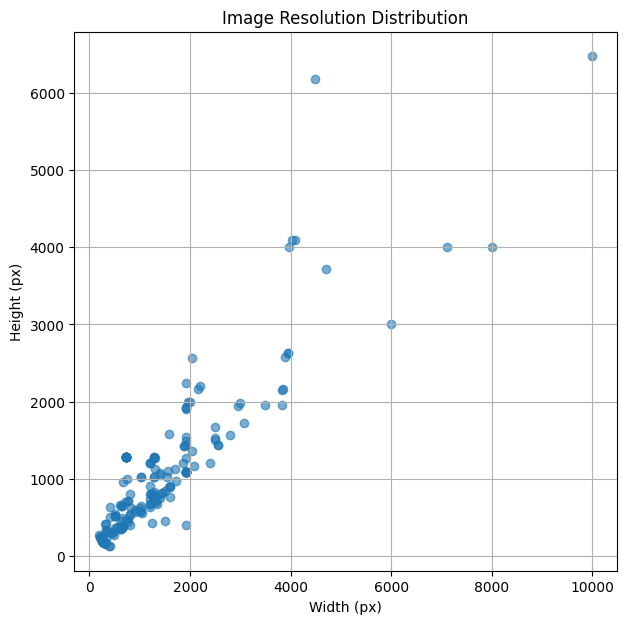

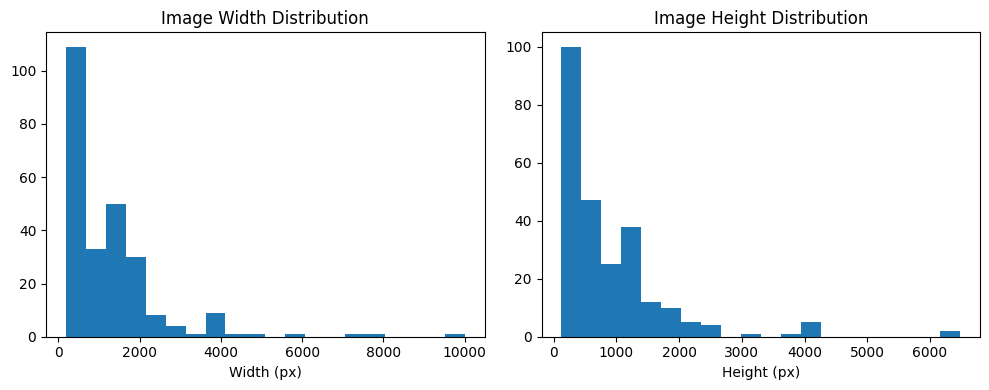

Most Common Image Resolutions:

width  height
300    168       15
225    225       13
720    1280      12
1280   720       11
1920   1080      11
275    183        5
259    194        4
299    168        4
1200   1200       3
251    201        3
dtype: int64


In [ ]:
image_dir = '/content/my_data/astronomy_dataset/images'

# Lists to store results
widths, heights = [], []

# Loop through all image paths in the dataframe
for img_name in df['image']:
    img_path = os.path.join('/content/my_data/astronomy_dataset', img_name)

    try:
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except Exception as e:
        print(f"Error reading {img_name}: {e}")
        widths.append(None)
        heights.append(None)

# Add to DataFrame
df['width'] = widths
df['height'] = heights

plt.figure(figsize=(7,7))
plt.scatter(df['width'], df['height'], alpha=0.6)
plt.title("Image Resolution Distribution")
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.grid(True)
plt.show()


plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(df['width'], bins=20)
plt.title("Image Width Distribution")
plt.xlabel("Width (px)")

plt.subplot(1,2,2)
plt.hist(df['height'], bins=20)
plt.title("Image Height Distribution")
plt.xlabel("Height (px)")

plt.tight_layout()
plt.show()


res_counts = df.groupby(['width','height']).size().sort_values(ascending=False)
print("Most Common Image Resolutions:\n")
print(res_counts.head(10))

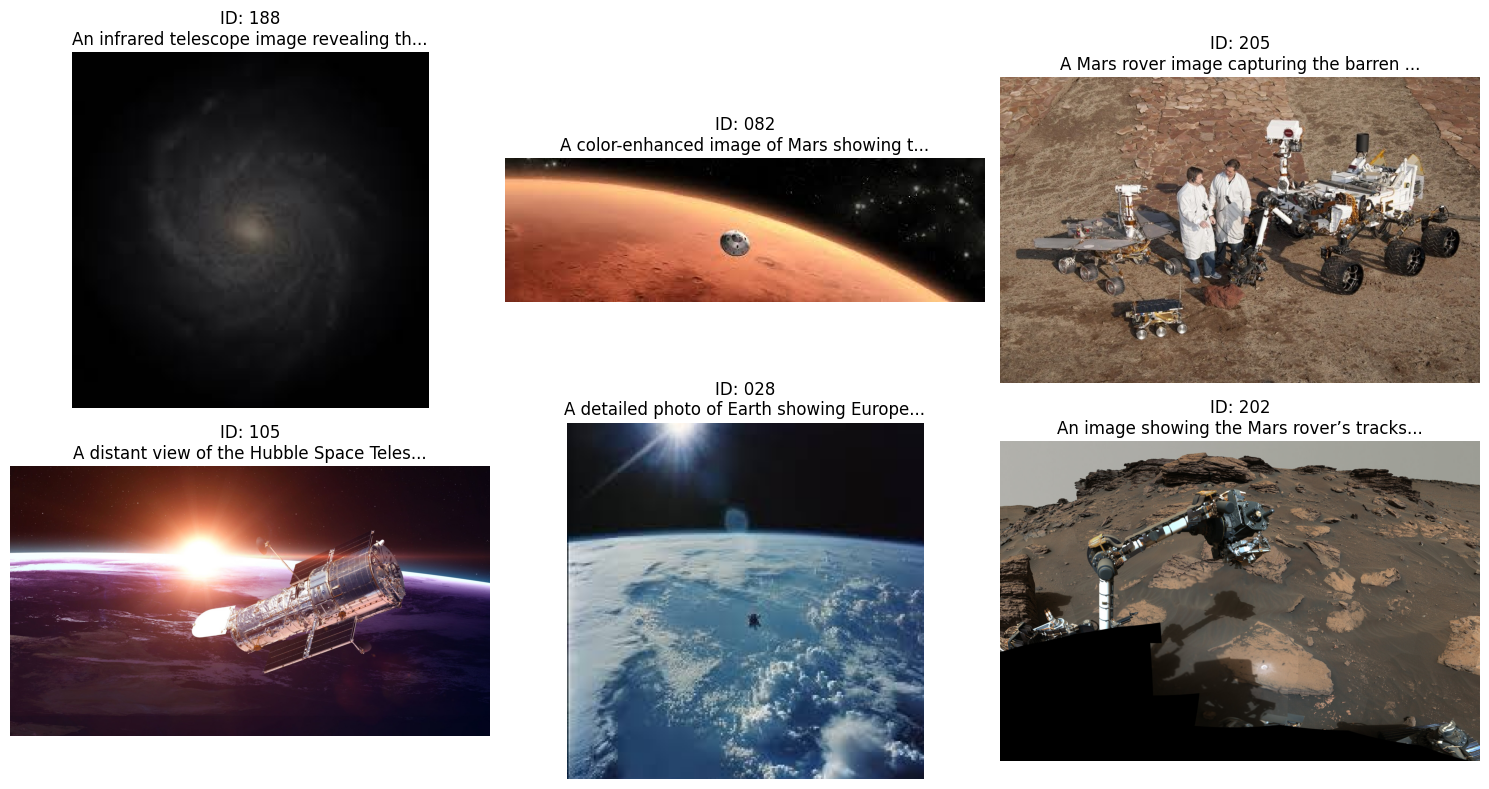

In [ ]:
def show_random_samples(df, n=6):
    # Pick n random samples
    samples = df.sample(n, random_state=random.randint(0, 10000))

    plt.figure(figsize=(15, 8))

    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join('/content/my_data/astronomy_dataset', row['image'])

        try:
            img = Image.open(img_path)
            plt.subplot(2, n//2, i+1)
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"ID: {row['image_id']}\n{row['text'][:40]}...")
        except Exception as e:
            print(f"Error loading {row['image_id']}: {e}")

    plt.tight_layout()
    plt.show()

show_random_samples(df, n=6)

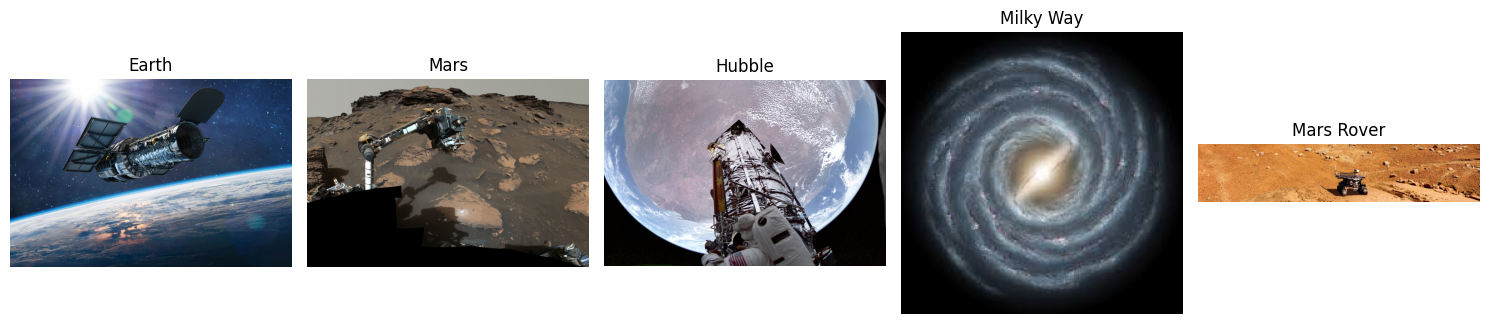

In [ ]:
def show_one_from_each(df):
    categories = ['Earth', 'Mars', 'Hubble', 'Milky Way', 'Mars Rover']

    plt.figure(figsize=(15, 5))
    for i, cat in enumerate(categories):
        # pick one random caption containing category name
        sample = df[df['text'].str.contains(cat, case=False, na=False)].sample(1)
        img_path = os.path.join('/content/my_data/astronomy_dataset', sample.iloc[0]['image'])

        img = Image.open(img_path)
        plt.subplot(1, len(categories), i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(cat)

    plt.tight_layout()
    plt.show()

show_one_from_each(df)

In [ ]:
def detect_label(text):
    text_lower = text.lower()
    if "earth" in text_lower:
        return "Earth"
    elif "mars" in text_lower and "rover" not in text_lower:
        return "Mars"
    elif "hubble" in text_lower:
        return "Hubble"
    elif "milky" in text_lower:
        return "Milky Way"
    elif "rover" in text_lower or "laboratory" in text_lower:
        return "Mars Rover"
    else:
        return "Unknown"

df['label'] = df['text'].apply(detect_label)

In [ ]:
label_counts = df['label'].value_counts()
print("Label Distribution:\n")
print(label_counts)

Label Distribution:

label
Earth         77
Mars Rover    46
Milky Way     45
Mars          42
Hubble        28
Unknown       12
Name: count, dtype: int64


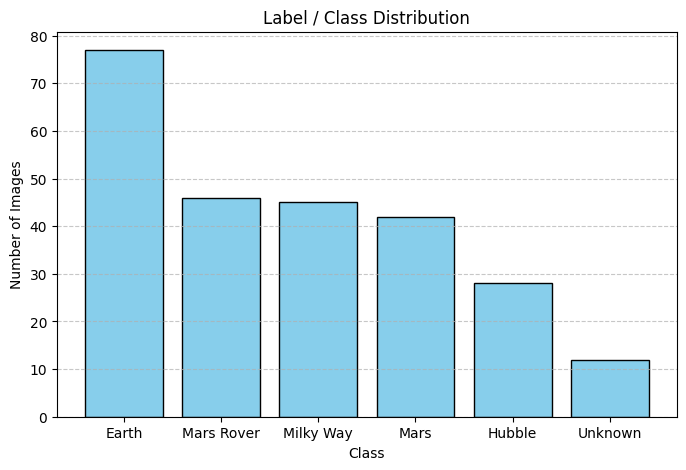

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(label_counts.index, label_counts.values, color='skyblue', edgecolor='black')
plt.title("Label / Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
unknowns = df[df['label'] == "Unknown"]
print("Images with Unknown label:")
print(unknowns[['image_id', 'text']].head())

Images with Unknown label:
   image_id                                               text
14      015  A detailed orbital photograph showing the Asia...
26      027  A high-altitude image showing the North Americ...
44      045  A view from orbit showing the African continen...
48      049  A satellite image showing the western hemisphe...
53      054  A detailed view of the Martian surface display...


# **Data Cleaning Steps**

In [ ]:
# Count missing or null captions
missing_count = df['text'].isnull().sum()
empty_count = (df['text'].str.strip() == "").sum()

print(f"Missing (NaN) captions: {missing_count}")
print(f"Empty ('') captions: {empty_count}")

# Remove rows where 'text' is null or empty
df = df[df['text'].notnull()]  # remove NaN
df = df[df['text'].str.strip() != ""]  # remove empty strings

# Reset index
df = df.reset_index(drop=True)

Missing (NaN) captions: 0
Empty ('') captions: 0


In [ ]:
print("After cleaning:")
print(f"Total remaining captions: {len(df)}")
print("Any nulls left?", df['text'].isnull().any())

After cleaning:
Total remaining captions: 250
Any nulls left? False


In [ ]:
def clean_caption(text):
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and digits (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
df['clean_text'] = df['text'].apply(clean_caption)

In [ ]:
print("Before cleaning:")
print(df['text'].sample(3, random_state=1).values)

print("\nAfter cleaning:")
print(df['clean_text'].sample(3, random_state=1).values)

Before cleaning:
['A natural color image of Mars displaying the Tharsis volcanic plateau and its massive shield volcanoes.'
 'A wide-angle image of the Mars rover exploring the red surface of Mars under a hazy sky.'
 'A panoramic image showing the Mars rover in a dusty Martian plain with distant hills.']

After cleaning:
['a natural color image of mars displaying the tharsis volcanic plateau and its massive shield volcanoes'
 'a wideangle image of the mars rover exploring the red surface of mars under a hazy sky'
 'a panoramic image showing the mars rover in a dusty martian plain with distant hills']


In [ ]:
df['text'] = df['clean_text']
df.drop(columns=['clean_text'], inplace=True)

In [ ]:
# Count duplicates before removal
duplicate_count = df.duplicated(subset='text').sum()
print(f"Duplicated captions found: {duplicate_count}")

# Drop duplicates
df = df.drop_duplicates(subset='text', keep='first').reset_index(drop=True)

print(f"Remaining captions after duplicate removal: {len(df)}")

Duplicated captions found: 0
Remaining captions after duplicate removal: 250


In [ ]:
# # Remove Extremely Short or Long Captions
# df['word_count'] = df['text'].apply(lambda x: len(x.split()))
# print(df['word_count'].describe())

# min_words = 3
# max_words = 50

# before = len(df)
# df = df[(df['word_count'] >= min_words) & (df['word_count'] <= max_words)].reset_index(drop=True)
# after = len(df)

# print(f"Removed {before - after} captions (too short or too long)")
# print(f"Remaining captions: {after}")

# df[['image_id', 'text', 'word_count']].sample(5, random_state=42)

In [ ]:
base_path = '/content/my_data/astronomy_dataset'  # main dataset folder, joins the images from JSON file

def is_valid_image(image_path):
    try:
        with Image.open(image_path) as img:
            img.verify()  # check integrity
        return True
    except Exception as e:
        # Print small info to trace later if needed
        print(f"Corrupted or missing: {image_path} ({e})")
        return False

valid_images = []
for img_rel_path in df['image']:
    img_abs_path = os.path.join(base_path, img_rel_path)
    valid_images.append(is_valid_image(img_abs_path))

df['valid_image'] = valid_images

In [ ]:
# Count invalid ones
invalid_count = (~df['valid_image']).sum()
print(f"Invalid or missing images found: {invalid_count}")

# Filter out invalid images
df = df[df['valid_image']].reset_index(drop=True)
df.drop(columns=['valid_image'], inplace=True)

print(f"Remaining valid images: {len(df)}")

Invalid or missing images found: 0
Remaining valid images: 250


In [ ]:
# # Filter very low image resolution
# min_width, min_height = 224, 224

# def is_high_res(image_path, min_w=224, min_h=224):
#     try:
#         with Image.open(image_path) as img:
#             width, height = img.size
#             return width >= min_w and height >= min_h
#     except Exception as e:
#         print(f"Error reading {image_path}: {e}")
#         return False

# high_res_flags = []

# for img_rel_path in df['image']:
#     img_abs_path = os.path.join(base_path, img_rel_path)
#     high_res_flags.append(is_high_res(img_abs_path))

# df['is_high_res'] = high_res_flags

# low_res_count = (~df['is_high_res']).sum()
# print(f"Low-resolution images found: {low_res_count}")

# # Keep only high-res images
# df = df[df['is_high_res']].reset_index(drop=True)
# df.drop(columns=['is_high_res'], inplace=True)

# print(f"Remaining images after filtering: {len(df)}")

In [ ]:
df

,image_id,text,image,text_length,word_count,language,width,height,label
0,001,a satellite image of earth showing the curvatu...,images/001.jpg,94,15,en,514,360,Earth
1,002,a view of earth from orbit highlighting the de...,images/002.jpg,99,16,en,626,352,Earth
2,003,an image of earth taken from space showing nor...,images/003.jpg,96,15,en,1920,1080,Earth
3,004,a highresolution view of earth revealing the a...,images/004.jpg,101,15,en,2000,2000,Earth
4,005,a spacebased image of earth showing the curvat...,images/005.jpg,107,17,en,736,460,Earth
...,...,...,...,...,...,...,...,...,...
245,246,a photo showing the mars rover collecting data...,images/246.jpg,92,16,en,1280,720,Mars Rover
246,247,a mars rover image capturing a dusty martian s...,images/247.jpg,98,16,en,1280,720,Mars Rover
247,248,a closeup photograph of a mars rover undergoin...,images/248.jpg,99,16,en,1280,1024,Earth
248,249,an image showing the mars rover in motion acro...,images/249.jpg,89,16,en,400,508,Mars Rover


In [ ]:
print(df.info())
print(df.isnull().sum())
print(df['image_id'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   image_id     250 non-null    object
 1   text         250 non-null    object
 2   image        250 non-null    object
 3   text_length  250 non-null    int64 
 4   word_count   250 non-null    int64 
 5   language     250 non-null    object
 6   width        250 non-null    int64 
 7   height       250 non-null    int64 
 8   label        250 non-null    object
dtypes: int64(4), object(5)
memory usage: 17.7+ KB
None
image_id       0
text           0
image          0
text_length    0
word_count     0
language       0
width          0
height         0
label          0
dtype: int64
image_id
001    1
002    1
003    1
004    1
005    1
      ..
246    1
247    1
248    1
249    1
250    1
Name: count, Length: 250, dtype: int64


# **Import Unsloth**

In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9\.]{3,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.32.post2" if v == "2.8.0" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets>=3.4.1,<4.0.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

# **Import the Targeted Model**

In [ ]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit", # Llama 3.2 vision support
    "unsloth/Llama-3.2-11B-Vision-bnb-4bit",
    "unsloth/Llama-3.2-90B-Vision-Instruct-bnb-4bit", # Can fit in a 80GB card!
    "unsloth/Llama-3.2-90B-Vision-bnb-4bit",

    "unsloth/Pixtral-12B-2409-bnb-4bit",              # Pixtral fits in 16GB!
    "unsloth/Pixtral-12B-Base-2409-bnb-4bit",         # Pixtral base model

    "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",          # Qwen2 VL support
    "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit",
    "unsloth/Qwen2-VL-72B-Instruct-bnb-4bit",

    "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit",      # Any Llava variant works!
    "unsloth/llava-1.5-7b-hf-bnb-4bit",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Llama-3.2-11B-Vision-Instruct",
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.11.2: Fast Mllama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.94G [00:00<?, ?B/s]

...

preprocessor_config.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

# **LoRA-based model fine-tuning setup for a vision-language model**

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

Unsloth: Making `model.base_model.model.model.vision_model.transformer` require gradients


# **Load Dataset from the DF**

In [ ]:
# Load directly from pandas DataFrame
hf_dataset = Dataset.from_pandas(df)

print(hf_dataset)

Dataset({
    features: ['image_id', 'text', 'image', 'text_length', 'word_count', 'language', 'width', 'height', 'label'],
    num_rows: 250
})


# **Data Preprocessing Steps**

In [ ]:
hf_dataset = hf_dataset.train_test_split(test_size=0.2, seed=42)
test_valid = hf_dataset['test'].train_test_split(test_size=0.5, seed=42)

train_dataset = hf_dataset['train']
valid_dataset = test_valid['train']
test_dataset  = test_valid['test']

print(f"Train: {len(train_dataset)}")
print(f"Valid: {len(valid_dataset)}")
print(f"Test:  {len(test_dataset)}")

Train: 200
Valid: 25
Test:  25


In [ ]:
base_path = "/content/my_data/astronomy_dataset"

def convert_to_conversation(sample):
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "You are an expert astronomer. Describe accurately what you see in this image."},
                {"type": "image", "image": os.path.join(base_path, sample["image"])},
            ],
        },
        {
            "role": "assistant",
            "content": [{"type": "text", "text": sample["text"]}],
        },
    ]
    return {"messages": conversation}

# Rebuild cleanly
converted_dataset = [convert_to_conversation(row) for _, row in df.iterrows()]
hf_dataset = Dataset.from_list(converted_dataset)

# Verify the first item
print(hf_dataset[0])

{'messages': [{'content': [{'image': None, 'text': 'You are an expert astronomer. Describe accurately what you see in this image.', 'type': 'text'}, {'image': '/content/my_data/astronomy_dataset/images/001.jpg', 'text': None, 'type': 'image'}], 'role': 'user'}, {'content': [{'image': None, 'text': 'a satellite image of earth showing the curvature and scattered clouds over the atlantic ocean', 'type': 'text'}], 'role': 'assistant'}]}


In [ ]:
FastVisionModel.for_inference(model)  # enables faster inference

# Load one sample from your cleaned dataframe
base_path = "/content/my_data/astronomy_dataset"  # folder containing 'images'
sample = df.iloc[0]

image_path = os.path.join(base_path, sample["image"])  # full path
image = Image.open(image_path).convert("RGB")

instruction = "You are an expert astronomer. Describe accurately what you see in this image."

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": instruction}
        ]
    }
]

input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)

inputs = tokenizer(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt",
).to("cuda")

from transformers import TextStreamer

text_streamer = TextStreamer(tokenizer, skip_prompt=True)

_ = model.generate(
    **inputs,
    streamer=text_streamer,
    max_new_tokens=128,
    use_cache=True,
    temperature=1.2,
    min_p=0.1
)

From the perspective of the moon's surface, the Earth appears as a majestic blue and white globe, illuminated by the radiant sun, set against the inky blackness of space, speckled with stars. The moon's surface, dominated by dark grey terrain, is characterized by numerous craters and rugged ridges, offering a stark contrast to the planet in the background. The image provides a breathtaking view of our planet, showcasing its unique features and the vast expanse of space. The overall scene is one of awe-inspiring beauty and a reminder of our world's place in the universe.<|eot_id|>


In [ ]:
print(image_path, os.path.exists(image_path))

/content/my_data/astronomy_dataset/images/001.jpg True


# **Model Fine-Tuning**

In [ ]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model)  # Enable training mode

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),  # Required for multimodal data
    train_dataset = hf_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 30,  # increase later for full runs
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)

In [ ]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.741 GB.
8.582 GB of memory reserved.


# **Fine-Tune the Model**

In [ ]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 250 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 67,174,400 of 10,737,395,235 (0.63% trained)


Step,Training Loss
1,3.927300
2,4.003100
3,3.773400
4,3.207200
5,3.062700
6,2.518100
7,1.874700
8,1.441800
9,1.281600
10,1.128800


In [ ]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

686.0076 seconds used for training.
11.43 minutes used for training.
Peak reserved memory = 10.049 GB.
Peak reserved memory for training = 1.467 GB.
Peak reserved memory % of max memory = 68.17 %.
Peak reserved memory for training % of max memory = 9.952 %.


# **Model Evaluation**

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)

base_path = "/content/my_data/astronomy_dataset"

def convert_to_conversation(sample):
    return {
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": "You are an expert astronomer. Describe accurately what you see in this image."},
                    {"type": "image", "image": os.path.join(base_path, sample["image"])},
                ],
            },
            {
                "role": "assistant",
                "content": [{"type": "text", "text": sample["text"]}],
            },
        ]
    }

test_converted = [convert_to_conversation(row) for _, row in test_df.iterrows()]
test_dataset = Dataset.from_list(test_converted)

In [ ]:
FastVisionModel.for_inference(model)  # Switch to inference mode

instruction = "You are an expert astronomer. Describe accurately what you see in this image."

predictions = []
references = []

for i in range(len(test_dataset)):
    sample = test_dataset[i]
    image_path = sample["messages"][0]["content"][1]["image"]
    gt_caption = sample["messages"][1]["content"][0]["text"]

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Prepare messages
    messages = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": instruction}
        ]}
    ]

    input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
    inputs = tokenizer(
        image,
        input_text,
        add_special_tokens=False,
        return_tensors="pt"
    ).to("cuda")

    # Generate prediction
    outputs = model.generate(**inputs, max_new_tokens=128, temperature=1.0, use_cache=True)
    pred_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    predictions.append(pred_text.strip())
    references.append(gt_caption.strip())

In [ ]:
!pip install evaluate -q
!pip install rouge_score -q

from evaluate import load

bleu = load("bleu")
rouge = load("rouge")

# Correct format for `evaluate`
bleu.add_batch(predictions=predictions, references=[[r] for r in references])
bleu_score = bleu.compute()

rouge.add_batch(predictions=predictions, references=references)
rouge_score = rouge.compute()

print("BLEU:", bleu_score)
print("ROUGE:", rouge_score)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


BLEU: {'bleu': 0.05371026334834362, 'precisions': [0.18932655654383734, 0.06824146981627296, 0.035278154681139755, 0.018258426966292134], 'brevity_penalty': 1.0, 'length_ratio': 2.0548302872062663, 'translation_length': 787, 'reference_length': 383}
ROUGE: {'rouge1': np.float64(0.265797283956264), 'rouge2': np.float64(0.0979276560777889), 'rougeL': np.float64(0.23834083240096982), 'rougeLsum': np.float64(0.2468568757495009)}


In [ ]:
for i in range(3):
    print(f"Image {i+1}")
    print("Predicted:", predictions[i])
    print("Reference:", references[i])
    print("-" * 50)

Image 1
Predicted: user

You are an expert astronomer. Describe accurately what you see in this image.assistant

a photograph of the hubble space telescope in orbit above earth illuminated by sunlight
Reference: an image showing hubbles metallic body glinting in sunlight with the darkness of space behind it
--------------------------------------------------
Image 2
Predicted: user

You are an expert astronomer. Describe accurately what you see in this image.assistant

a photograph of earth taken from space showing the continent of africa surrounded by ocean
Reference: a distant perspective of earth capturing the blue oceans and swirling atmosphere against the blackness of space
--------------------------------------------------
Image 3
Predicted: user

You are an expert astronomer. Describe accurately what you see in this image.assistant

an orbital image of the mars spacecraft orbiting above the martian surface with the martian terrain visible beneath
Reference: a detailed orbital vie

In [ ]:
# Enable inference mode
FastVisionModel.for_inference(model)

# Use one example from your cleaned Hugging Face test dataset
sample = test_dataset[0]  # or any index you like

# Get image path and caption
image_path = sample["messages"][0]["content"][1]["image"]
instruction = "You are an expert astronomer. Describe accurately what you see in this image."

# Load image
image = Image.open(image_path).convert("RGB")

# Prepare chat messages
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": instruction}
        ]
    }
]

# Apply template
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)

# Tokenize both image + text
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt"
).to("cuda")

# Stream and generate
text_streamer = TextStreamer(tokenizer, skip_prompt=True)
_ = model.generate(
    **inputs,
    streamer=text_streamer,
    max_new_tokens=128,
    use_cache=True,
    temperature=1.5,  # you can raise this (e.g., 1.3–1.5) for more creative output
    min_p=0.1
)

a satellite orbiting earth at night illuminated by stars reflecting on its polished surfaces<|eot_id|>


In [ ]:
test_dataset[0]

{'messages': [{'content': [{'image': None,
     'text': 'You are an expert astronomer. Describe accurately what you see in this image.',
     'type': 'text'},
    {'image': '/content/my_data/astronomy_dataset/images/143.jpg',
     'text': None,
     'type': 'image'}],
   'role': 'user'},
  {'content': [{'image': None,
     'text': 'an image showing hubbles metallic body glinting in sunlight with the darkness of space behind it',
     'type': 'text'}],
   'role': 'assistant'}]}

# **Testing the Model with Explicit Image**

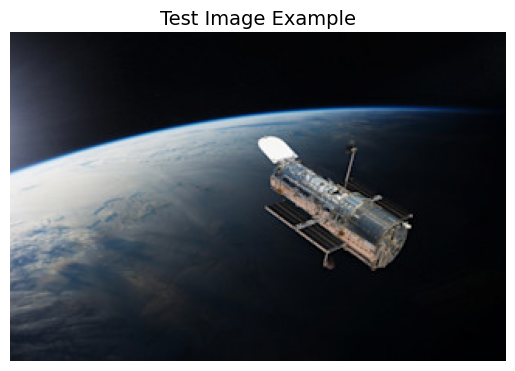

Ground Truth Caption:
an image showing hubbles metallic body glinting in sunlight with the darkness of space behind it

Model Prediction:
user

You are an expert astronomer. Describe accurately what you see in this image.assistant

a close up view of the hubble space telescope in orbit above the earth


In [ ]:
# Enable inference mode
FastVisionModel.for_inference(model)

# Pick one example from the test dataset
sample = test_dataset[0]

# Get image path and ground truth caption (if available)
image_path = sample["messages"][0]["content"][1]["image"]
true_caption = sample["messages"][1]["content"][0]["text"]

# Load image
image = Image.open(image_path).convert("RGB")

# Instruction for the model
instruction = "You are an expert astronomer. Describe accurately what you see in this image."

# Prepare chat input
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": instruction}
        ]
    }
]

# Apply chat template
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)

# Tokenize
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt"
).to("cuda")

# Generate response
text_streamer = TextStreamer(tokenizer, skip_prompt=True)
generated = model.generate(
    **inputs,
    max_new_tokens=128,
    use_cache=True,
    temperature=1.5,
    min_p=0.1
)

# Decode the output text
generated_text = tokenizer.decode(generated[0], skip_special_tokens=True)

# Plot image + show captions
plt.imshow(image)
plt.axis("off")
plt.title("Test Image Example", fontsize=14)
plt.show()

print("Ground Truth Caption:")
print(true_caption)
print("\nModel Prediction:")
print(generated_text)

# **Model Checkpoint Save Cell**

In [ ]:
# Save locally to 16bit
if False: model.save_pretrained_merged("unsloth_finetune", tokenizer)

In [ ]:
!ls

drive  my_data	outputs  sample_data  unsloth_compiled_cache


# **Final Model Export/Save Cell**

In [ ]:
model.save_pretrained_merged("unsloth_finetune", tokenizer)

config.json: 0.00B [00:00, ?B/s]

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Checking cache directory for required files...
Cache check failed: model-00001-of-00005.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


...

model-00005-of-00005.safetensors:   0%|          | 0.00/1.47G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 5/5 [07:08<00:00, 85.78s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 5/5 [05:46<00:00, 69.40s/it]


Unsloth: Merge process complete. Saved to `/content/unsloth_finetune`


In [ ]:
###### RUNNING THIS WITH YOUR OWN RISK ######
###### RUN THIS WHEN YOU JUST NEED IT ######

import shutil
from google.colab import files

# Create ZIP of the entire fine-tuned model folder
shutil.make_archive("unsloth_finetune", 'zip', "unsloth_finetune")

# Download the ZIP file to your local computer
files.download("unsloth_finetune.zip")

In [ ]:
###### RUNNING THIS WITH YOUR OWN RISK ######
###### RUN THIS WHEN YOU JUST NEED IT ######

# Mount Drive
drive.mount('/content/drive')

# Copy the folder to your Drive
shutil.copytree("unsloth_finetune", "/content/drive/MyDrive/unsloth_finetune")

In [ ]:
###### RUNNING THIS WITH YOUR OWN RISK ######
###### RUN THIS WHEN YOU JUST NEED IT ######

# Mount your Google Drive
drive.mount('/content/drive')

# Copy only the specific safetensors file
src = "unsloth_finetune/model-00005-of-00005.safetensors"
dst = "/content/drive/MyDrive/model-00005-of-00005.safetensors"

shutil.copy(src, dst)
print("File copied successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File copied successfully!


In [ ]:
###### RUNNING THIS WITH YOUR OWN RISK ######
###### RUN THIS WHEN YOU JUST NEED IT ######

# Load for deployment in Google Colab
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model_path = "/content/unsloth_finetune"

# Load the merged fine-tuned model
model, tokenizer = FastVisionModel.from_pretrained(
    model_path,
    load_in_4bit=False,           # 16-bit instead of 4-bit
    use_gradient_checkpointing="unsloth",
    device_map="auto"              # auto splits layers across GPU and CPU
)

FastVisionModel.for_inference(model)
print("Model loaded successfully!")

# **Login to Your Hugging Face Account**

In [ ]:
from huggingface_hub import login
login(new_session=True)

# **Sure is the Right Account**

In [4]:
from huggingface_hub import whoami
print(whoami())

{'type': 'user', 'id': '6901e7c98888e4646b8e6aa1', 'name': 'AIOmarRehan', 'fullname': 'Rehan', 'email': 'ai.omar.rehan@gmail.com', 'emailVerified': True, 'canPay': False, 'periodEnd': None, 'isPro': False, 'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/no-auth/fbFFS53Ke8a3CKUn-ayeA.png', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'LLaMA_11B_Vision', 'role': 'write', 'createdAt': '2025-11-08T11:27:37.905Z'}}}


# **Push LoRA Weights to your Account's Repo**

In [6]:
model.push_to_hub("Omarinooooo/my-llama-lora", tokenizer=tokenizer)

README.md:  100%
634/634 [00:00<00:00, 71.0kB/s]

Processing Files (1 / 1)    100%
████████████████████████████████████████████████████████████████████████ 269MB / 269MB, 26.9MB/s

New Data Upload            100%
████████████████████████████████████████████████████████████████████████ 262MB / 262MB, 26.2MB/s

...adapter_model.safetensors: 100%
████████████████████████████████████████████████████████████████████████ 269MB / 269MB

Saved model to https://huggingface.co/AIOmarRehan/Llama-3.2-11B-Vision-LoRA-on-Astronomy-with-Unsloth
